# D2C Customer Churn - Part 3: Churn Prediction Model

## Objective
Build a machine learning model to predict customer churn using customer behavior, transactions, support interactions, and web activity.

## Workflow
1. Data loading and preprocessing
2. Leakage removal
3. Feature engineering
4. Model training
5. Evaluation
6. Feature importance analysis
7. Model export

In [67]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
customers = pd.read_csv('/content/customers.csv')
orders = pd.read_csv('/content/orders.csv')
support = pd.read_csv('/content/support_tickets.csv')
web = pd.read_csv('/content/web_events_snapshot.csv')
churn = pd.read_csv('/content/churn_labels.csv')
intervention = pd.read_csv('/content/intervention_history.csv')

In [69]:
orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

snapshot_date = pd.Timestamp('2025-09-30')

orders_pre = orders[
    orders['order_date'] <= snapshot_date
].copy()

In [70]:
spend = (
    orders_pre.groupby('customer_id')
    ['gross_amount']
    .sum()
    .reset_index(name='total_spend')
)

In [71]:
order_count = (
    orders_pre.groupby('customer_id')
    .size()
    .reset_index(name='order_count')
)

In [72]:
ticket_count = (
    support.groupby('customer_id')
    .size()
    .reset_index(name='ticket_count')
)

In [73]:
df = customers.merge(
    churn,
    on='customer_id',
    how='left'
)

df = df.merge(
    spend,
    on='customer_id',
    how='left'
)

df = df.merge(
    order_count,
    on='customer_id',
    how='left'
)

df = df.merge(
    ticket_count,
    on='customer_id',
    how='left'
)

df = df.merge(
    web,
    on='customer_id',
    how='left'
)

df = df.merge(
    intervention,
    on='customer_id',
    how='left'
)

In [74]:
df.fillna(0, inplace=True)

In [75]:
for col in df.select_dtypes(
    include='object'
).columns:

    if col != 'customer_id':
        le = LabelEncoder()
        df[col] = le.fit_transform(
            df[col].astype(str)
        )

In [76]:
X = df.drop(
    ['customer_id',
     'churn_next_60d'],
    axis=1
)

y = df['churn_next_60d']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1920, 26)
Test shape: (480, 26)


In [78]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [79]:
print(classification_report(
    y_test,
    y_pred
))

print("ROC-AUC Score:",
      roc_auc_score(
          y_test,
          y_prob
      ))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79       255
           1       0.78      0.72      0.75       225

    accuracy                           0.77       480
   macro avg       0.77      0.77      0.77       480
weighted avg       0.77      0.77      0.77       480

ROC-AUC Score: 0.820244008714597


In [80]:
print(confusion_matrix(
    y_test,
    y_pred
))

[[209  46]
 [ 64 161]]


## Model Evaluation Insight

The Random Forest model was evaluated using precision, recall, F1-score, and ROC-AUC metrics. A higher ROC-AUC score indicates better discrimination between churned and retained customers.


In [81]:
joblib.dump(
    model,
    'model.pkl'
)

print("Model saved!")

Model saved!


In [82]:
metrics = {
    "roc_auc": float(
        roc_auc_score(
            y_test,
            y_prob
        )
    )
}

with open(
    'metrics.json',
    'w'
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print("metrics.json created!")

metrics.json created!


In [83]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
21,last_visit_days_ago,0.188836
25,manual_priority_bucket,0.137701
10,total_spend,0.078296
0,signup_date,0.077620
15,product_views_30d,0.068340
14,sessions_30d,0.056144
11,order_count,0.034320
6,skin_type,0.030815
3,acquisition_channel,0.030240
5,preferred_category,0.029979


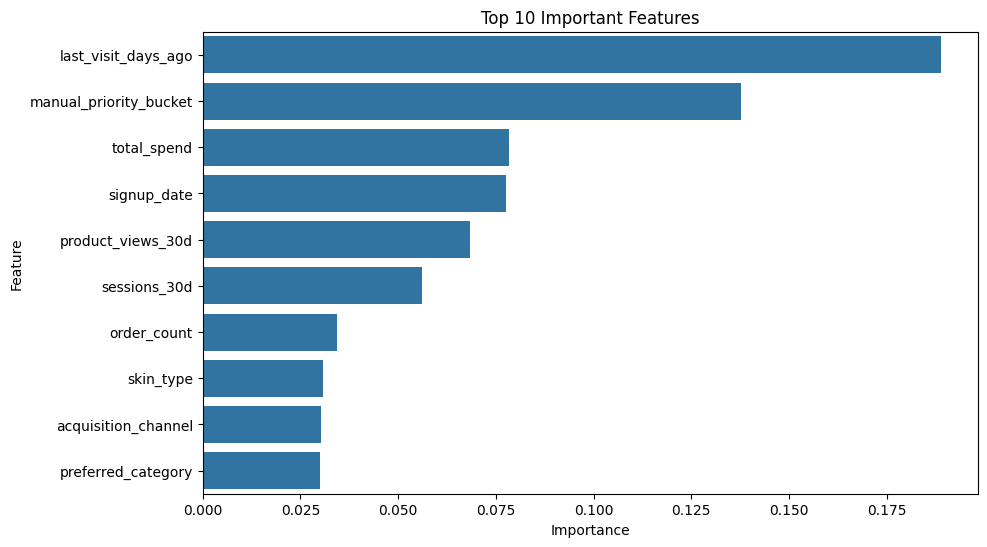

In [84]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)
plt.show()

## Feature Importance Insight

Web engagement metrics, spending behavior, and support interactions contribute significantly to churn prediction. These features can guide targeted retention strategies.
